# Comparación de Métricas: Con vs Sin Interpolación

Este notebook visualiza las diferencias entre análisis con y sin interpolación de trayectorias.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

In [ ]:
# Cargar datos
df = pd.read_csv('../../data/comparison_metrics_diff.csv')
print(f"Total métricas comparadas: {len(df)}")
df.head()

## Top 20 métricas con mayor diferencia

In [4]:
# Ordenar por diferencia absoluta
df_sorted = df.sort_values('abs_mean_diff_pct', ascending=False)

# Top 20
top20 = df_sorted.head(20)[['metric', 'mean_diff_pct', 'median_diff_pct', 'p5_diff_pct', 'p95_diff_pct']]
top20

,metric,mean_diff_pct,median_diff_pct,p5_diff_pct,p95_diff_pct
0,non_cut_mean_acceleration,-93.530130,-96.923194,-102.320839,-83.231397
1,mean_acceleration,-91.210560,-94.296330,-99.521974,-68.787302
2,non_cut_mean_abs_acceleration,-51.829057,-51.686433,-74.865494,-29.974295
3,mean_abs_acceleration,-50.706913,-50.865737,-75.018335,-27.065954
4,non_cut_search_avg_speed,-50.018386,-51.111760,-73.260714,-22.593900
5,search_avg_speed,-49.398063,-50.836433,-73.962860,-19.963346
6,non_cut_std_acceleration,-45.741487,-44.279100,-79.517114,-22.031346
7,std_acceleration,-44.581552,-43.091292,-78.076177,-20.484959
8,non_cut_mean_negative_acceleration,-44.194071,-43.903657,-67.338385,-21.266620
9,non_cut_peak_acceleration,-44.158489,-43.663898,-91.619114,0.776906


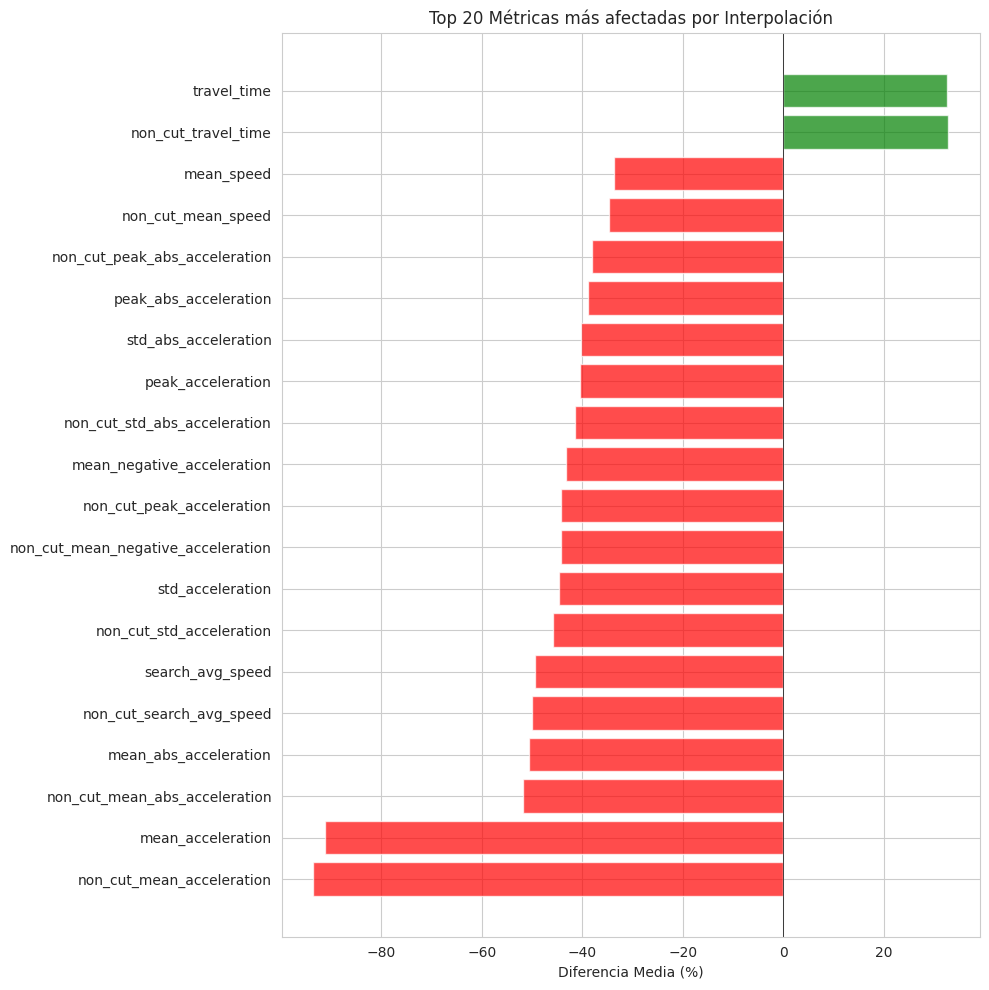

In [5]:
# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 10))

colors = ['red' if x < 0 else 'green' for x in df_sorted.head(20)['mean_diff_pct']]
ax.barh(df_sorted.head(20)['metric'], df_sorted.head(20)['mean_diff_pct'], color=colors, alpha=0.7)
ax.set_xlabel('Diferencia Media (%)')
ax.set_title('Top 20 Métricas más afectadas por Interpolación')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Métricas por categoría

In [6]:
# Clasificar métricas por tipo
def classify_metric(name):
    name_lower = name.lower()
    if 'acceleration' in name_lower:
        return 'Aceleración'
    elif 'speed' in name_lower:
        return 'Velocidad'
    elif 'distance' in name_lower:
        return 'Distancia'
    elif 'time' in name_lower or name_lower in ['rt']:
        return 'Tiempo'
    elif 'hesitation' in name_lower or 'search' in name_lower or 'travel' in name_lower:
        return 'Segmentación'
    else:
        return 'Otras'

df['category'] = df['metric'].apply(classify_metric)

# Resumen por categoría
summary = df.groupby('category').agg({
    'mean_diff_pct': ['mean', 'min', 'max'],
    'metric': 'count'
}).round(2)
summary.columns = ['Mean Δ%', 'Min Δ%', 'Max Δ%', 'N métricas']
summary.sort_values('Mean Δ%')

,Mean Δ%,Min Δ%,Max Δ%,N métricas
category,,,,
Aceleración,-44.62,-93.53,-14.30,18
Velocidad,-22.73,-50.02,-7.65,13
Segmentación,-8.42,-14.36,-2.25,4
Distancia,-1.65,-24.32,26.55,10
Otras,-1.25,-8.96,3.13,21
Tiempo,1.99,-13.29,32.82,11


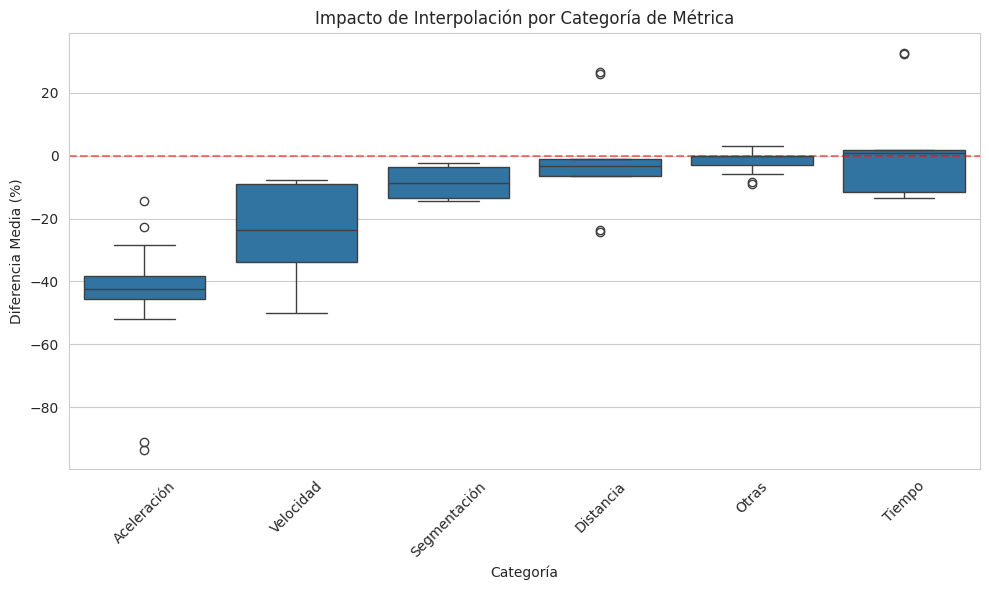

In [7]:
# Boxplot por categoría
fig, ax = plt.subplots(figsize=(10, 6))
order = df.groupby('category')['mean_diff_pct'].mean().sort_values().index
sns.boxplot(data=df, x='category', y='mean_diff_pct', order=order, ax=ax)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Categoría')
ax.set_ylabel('Diferencia Media (%)')
ax.set_title('Impacto de Interpolación por Categoría de Métrica')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Métricas de velocidad (detalle)

In [8]:
# Filtrar métricas de velocidad
speed_metrics = df[df['category'] == 'Velocidad'].sort_values('mean_diff_pct')
speed_metrics[['metric', 'mean_diff_pct', 'median_diff_pct', 'p5_diff_pct', 'p95_diff_pct']]

,metric,mean_diff_pct,median_diff_pct,p5_diff_pct,p95_diff_pct
4,non_cut_search_avg_speed,-50.018386,-51.111760,-73.260714,-22.593900
5,search_avg_speed,-49.398063,-50.836433,-73.962860,-19.963346
16,non_cut_mean_speed,-34.696234,-34.231272,-55.883673,-14.164766
17,mean_speed,-33.697182,-33.230448,-56.606440,-11.828314
22,non_cut_hesitation_avg_speed,-26.858281,-24.454230,-55.998742,-5.565126
26,speed_threshold,-24.088879,-22.805528,-46.559060,-6.807457
28,hesitation_avg_speed,-23.615328,-20.961929,-56.978336,-1.371512
37,non_cut_travel_avg_speed,-9.508958,-8.417208,-23.816590,1.067171
38,non_cut_peak_speed,-9.322070,-6.539094,-30.318450,2.818129
39,travel_avg_speed,-8.977380,-7.839247,-24.106701,2.044679


## Métricas de aceleración (detalle)

In [9]:
# Filtrar métricas de aceleración
acc_metrics = df[df['category'] == 'Aceleración'].sort_values('mean_diff_pct')
acc_metrics[['metric', 'mean_diff_pct', 'median_diff_pct', 'p5_diff_pct', 'p95_diff_pct']]

,metric,mean_diff_pct,median_diff_pct,p5_diff_pct,p95_diff_pct
0,non_cut_mean_acceleration,-93.530130,-96.923194,-102.320839,-83.231397
1,mean_acceleration,-91.210560,-94.296330,-99.521974,-68.787302
2,non_cut_mean_abs_acceleration,-51.829057,-51.686433,-74.865494,-29.974295
3,mean_abs_acceleration,-50.706913,-50.865737,-75.018335,-27.065954
6,non_cut_std_acceleration,-45.741487,-44.279100,-79.517114,-22.031346
7,std_acceleration,-44.581552,-43.091292,-78.076177,-20.484959
8,non_cut_mean_negative_acceleration,-44.194071,-43.903657,-67.338385,-21.266620
9,non_cut_peak_acceleration,-44.158489,-43.663898,-91.619114,0.776906
10,mean_negative_acceleration,-43.329927,-43.411232,-68.014401,-19.300974
11,non_cut_std_abs_acceleration,-41.553409,-39.492681,-80.766529,-15.105263


## Métricas que NO deberían cambiar

In [10]:
# Métricas con cambio < 1%
stable = df[df['abs_mean_diff_pct'] < 1].sort_values('abs_mean_diff_pct')
print(f"Métricas estables (<1% cambio): {len(stable)}")
stable[['metric', 'mean_diff_pct', 'category']]

Métricas estables (<1% cambio): 14


,metric,mean_diff_pct,category
71,trial_order_of_appearance,0.000000,Otras
72,px2mm,0.000000,Otras
73,age,0.000000,Otras
74,correct_targets_touches,0.000000,Otras
75,scale_factor,0.000000,Otras
76,non_cut_rt,0.000000,Otras
70,non_cut_correct_targets_touches,0.035128,Otras
69,letter_to_number_latency,0.055465,Otras
68,area_difference_from_ideal,-0.061260,Otras
67,rt,-0.074467,Tiempo


## Conclusiones

In [11]:
print("="*60)
print("RESUMEN DEL IMPACTO DE INTERPOLACIÓN")
print("="*60)
print(f"\nTotal métricas analizadas: {len(df)}")
print(f"Métricas con cambio >20%: {len(df[df['abs_mean_diff_pct'] > 20])}")
print(f"Métricas con cambio <1%: {len(df[df['abs_mean_diff_pct'] < 1])}")

print("\n--- Por categoría ---")
for cat in ['Aceleración', 'Velocidad', 'Segmentación', 'Distancia', 'Tiempo']:
    cat_df = df[df['category'] == cat]
    if len(cat_df) > 0:
        mean_change = cat_df['mean_diff_pct'].mean()
        print(f"{cat}: {mean_change:+.1f}% promedio ({len(cat_df)} métricas)")

RESUMEN DEL IMPACTO DE INTERPOLACIÓN

Total métricas analizadas: 77
Métricas con cambio >20%: 30
Métricas con cambio <1%: 14

--- Por categoría ---
Aceleración: -44.6% promedio (18 métricas)
Velocidad: -22.7% promedio (13 métricas)
Segmentación: -8.4% promedio (4 métricas)
Distancia: -1.7% promedio (10 métricas)
Tiempo: +2.0% promedio (11 métricas)
